# Explore here

Campaña de Marketing Bancario
Comprensión empresarial

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre bank-marketing-campaign-data.csv, y puedes cargarlo en el código directamente desde el siguiente enlace:


PARTE 1

1. CONOCIENDO EL DATASET

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

#Data collection
df = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv",sep=";")



df.info()
print("--------------------------------------------------------------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [65]:
df.shape

(41188, 21)

In [66]:
# revisando nulos
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Conclusiones del dataset:
- el dataset tiene 41188 filas y 21 columnas
- No hay valores nulos
- Se visualizan 11 variables categóricas y 10 vairables numéricas.

2. ELIMINACIÓN DE DUPLICADOS

In [67]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
df_duplicados = df[duplicados]
print("Filas duplicadas:")
print(df_duplicados)

# Eliminar duplicados
#usar el método drop.duplicated() para eliminar filas duplicadas

df = df.drop_duplicates().reset_index(drop=True)

print ("="*80)

print(f"Shape sin duplicados: {df.shape}")

El dataset tiene 12 filas duplicadas
Filas duplicadas:
       age          job   marital            education  default housing loan  \
1266    39  blue-collar   married             basic.6y       no      no   no   
12261   36      retired   married              unknown       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
16956   47   technician  divorced          high.school       no     yes   no   
18465   32   technician    single  professional.course       no     yes   no   
20216   55     services   married          high.school  unknown      no   no   
20534   41   technician   married  professional.course       no     yes   no   
25217   39       admin.   married    university.degree       no      no   no   
28477   24     services    single          high.school       no     yes   no   
32516   35       admin.   married    university.degree       no     yes   no   
36951   45       admin.   married    university.degree       no  

conclusión:
Se eliminaron 12 filas duplicadas, ahora el df tiene  41176 registros.

3. Selección de atributos relevantes

In [68]:
#-------------------------3. Selección de atributos relevantes-------------------
df.drop(["duration","day_of_week"], axis = 1, inplace = True)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


conclusión: se quitan las variables duration y day_of_week ya que con campos que dan característica de la llamada, se cree que la duración de la llamada no se puede predecir, y tmbn el día de la semana que se contacta al cliente no tendría tanta relevancia a la hora de definir si contrata un depósito, 

4. Análisis univariante

In [69]:
#chequeo de campos en df
df.info()
print("==============================================================")
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  str    
 2   marital         41176 non-null  str    
 3   education       41176 non-null  str    
 4   default         41176 non-null  str    
 5   housing         41176 non-null  str    
 6   loan            41176 non-null  str    
 7   contact         41176 non-null  str    
 8   month           41176 non-null  str    
 9   campaign        41176 non-null  int64  
 10  pdays           41176 non-null  int64  
 11  previous        41176 non-null  int64  
 12  poutcome        41176 non-null  str    
 13  emp.var.rate    41176 non-null  float64
 14  cons.price.idx  41176 non-null  float64
 15  cons.conf.idx   41176 non-null  float64
 16  euribor3m       41176 non-null  float64
 17  nr.employed     41176 non-null  float64
 1

(41176, 19)

4.1. Análisis sobre variables categóricas

In [70]:
# ---------------------------Análisis sobre variables categóricas
# revisión de valores repetidos por:
print(df.default.value_counts())
print("="*80)
print(df.housing.value_counts())
print("="*80)
print(df.loan.value_counts())
print("="*80)
print(df.contact.value_counts())


default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64
loan
no         33938
yes         6248
unknown      990
Name: count, dtype: int64
contact
cellular     26135
telephone    15041
Name: count, dtype: int64


In [71]:
# Ver cuántos valores únicos y cuáles son
print(f"valores únicos:",df['job'].nunique())      # solo el número
print("="*50)
print(df['job'].value_counts()) # el número y cuántas veces aparece cada uno

valores únicos: 12
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


/tmp/ipykernel_12572/1323932437.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90)  #ajustar nombres de etiquetas en education


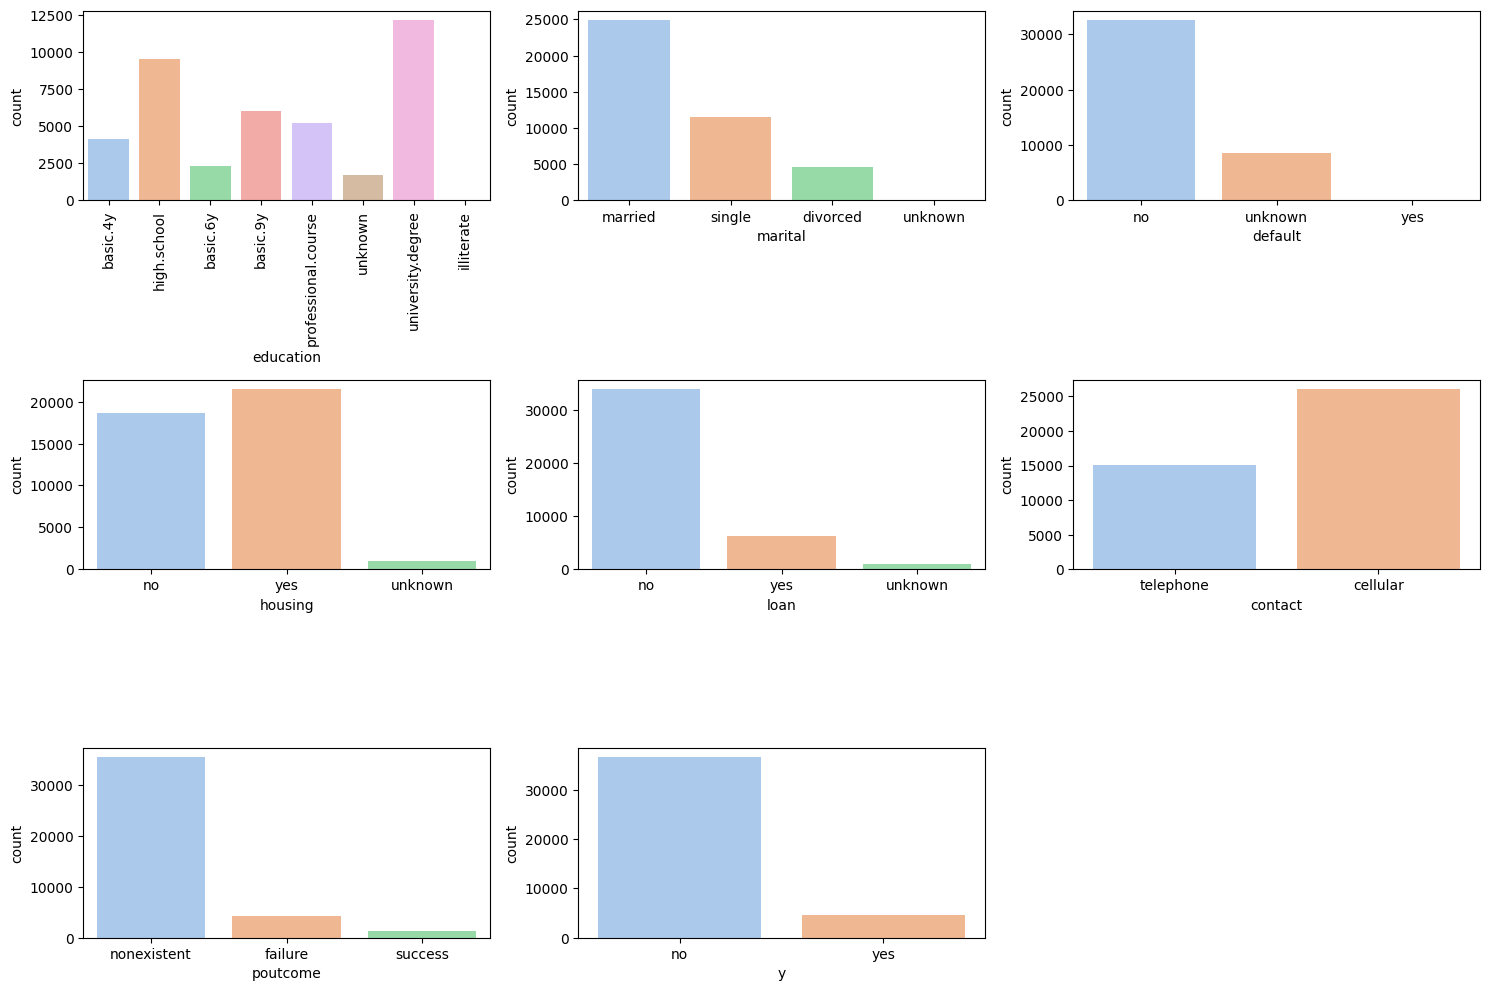

In [72]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.countplot(ax = axis[0, 0], data = df, x = "education", palette='pastel', hue= "education", legend=False)
sns.countplot(ax = axis[0, 1], data = df, x = "marital", palette='pastel', hue= "marital", legend=False)
sns.countplot(ax = axis[0, 2], data = df, x = "default", palette='pastel', hue= "default", legend=False)
sns.countplot(ax = axis[1, 0], data = df, x = "housing", palette='pastel', hue= "housing", legend=False)
sns.countplot(ax = axis[1, 1], data = df, x = "loan", palette='pastel', hue= "loan", legend=False)
sns.countplot(ax = axis[1, 2], data = df, x = "contact", palette='pastel', hue= "contact", legend=False)
sns.countplot(ax = axis[2, 0], data = df, x = "poutcome", palette='pastel', hue= "poutcome", legend=False)
sns.countplot(ax = axis[2, 1], data = df, x = "y", palette='pastel', hue= "y", legend=False)

axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90)  #ajustar nombres de etiquetas en education
axis[2, 2].set_visible(False)  
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

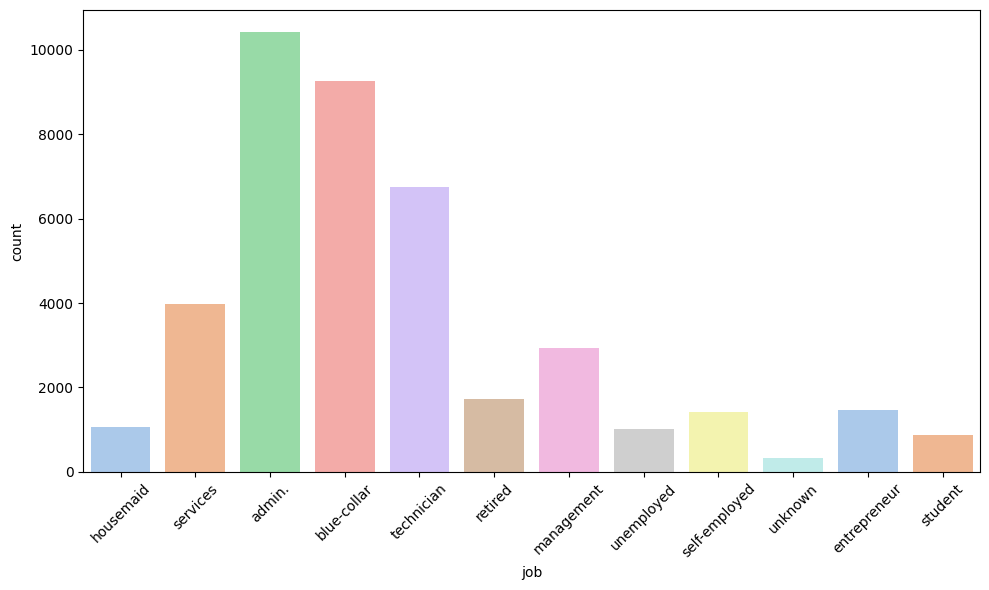

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="job", palette='pastel', hue="job", legend=False, ax=ax)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

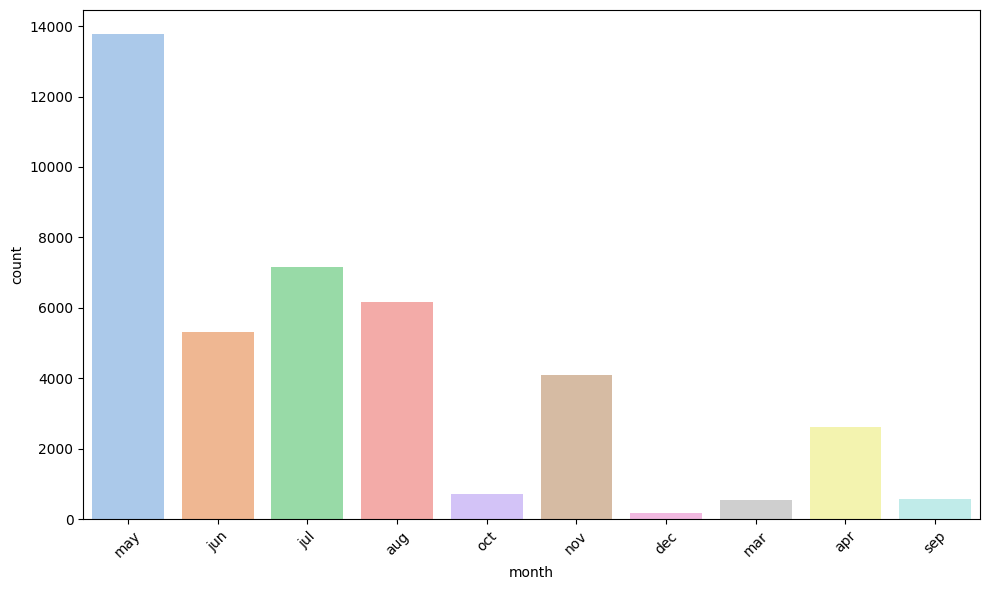

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="month", palette='pastel', hue="month", legend=False, ax=ax)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

conclusiones:
- education: La categoría más frecuente es university_degree, seguido de high school. Esto indica que la mayoría de los clientes tienen un nivel educativo universitario.
- marital: La mayoría de los clientes son casados.
- default: La gran mayoría tienen valor no, lo que significa que casi ningún cliente tiene crédito actualmente.
- housing: Se visualiza un reparto bastante equilibrado entre los que si tienen si tienenn préstamo de vivienda y los que no.
- loan: La mayoría de clientes no tiene préstamo personal, considedrando que son más de 30mil clientes (según gráfico)
- contact: El método de contacto más usado es el celular.
- poutcome: La mayoría de clientes tiene valor no existente, lo que significa que la mayoría de los clientes son nuevos (no han contactado antes). Solo un pequeño porcentaje tuvo éxito en campañas anteriores.
- y: Según el dataset, la mayoría de clientes que respondieron no a obtener un depósito a largo plazo.
- job: La mayoría de clientes tienen ocupación de tipo admin. seguido de blue-collar.
- month: Se puede decir que mayo es el mes con más contactos con el cliente. 

4.2. Análisis sobre variable numéricas

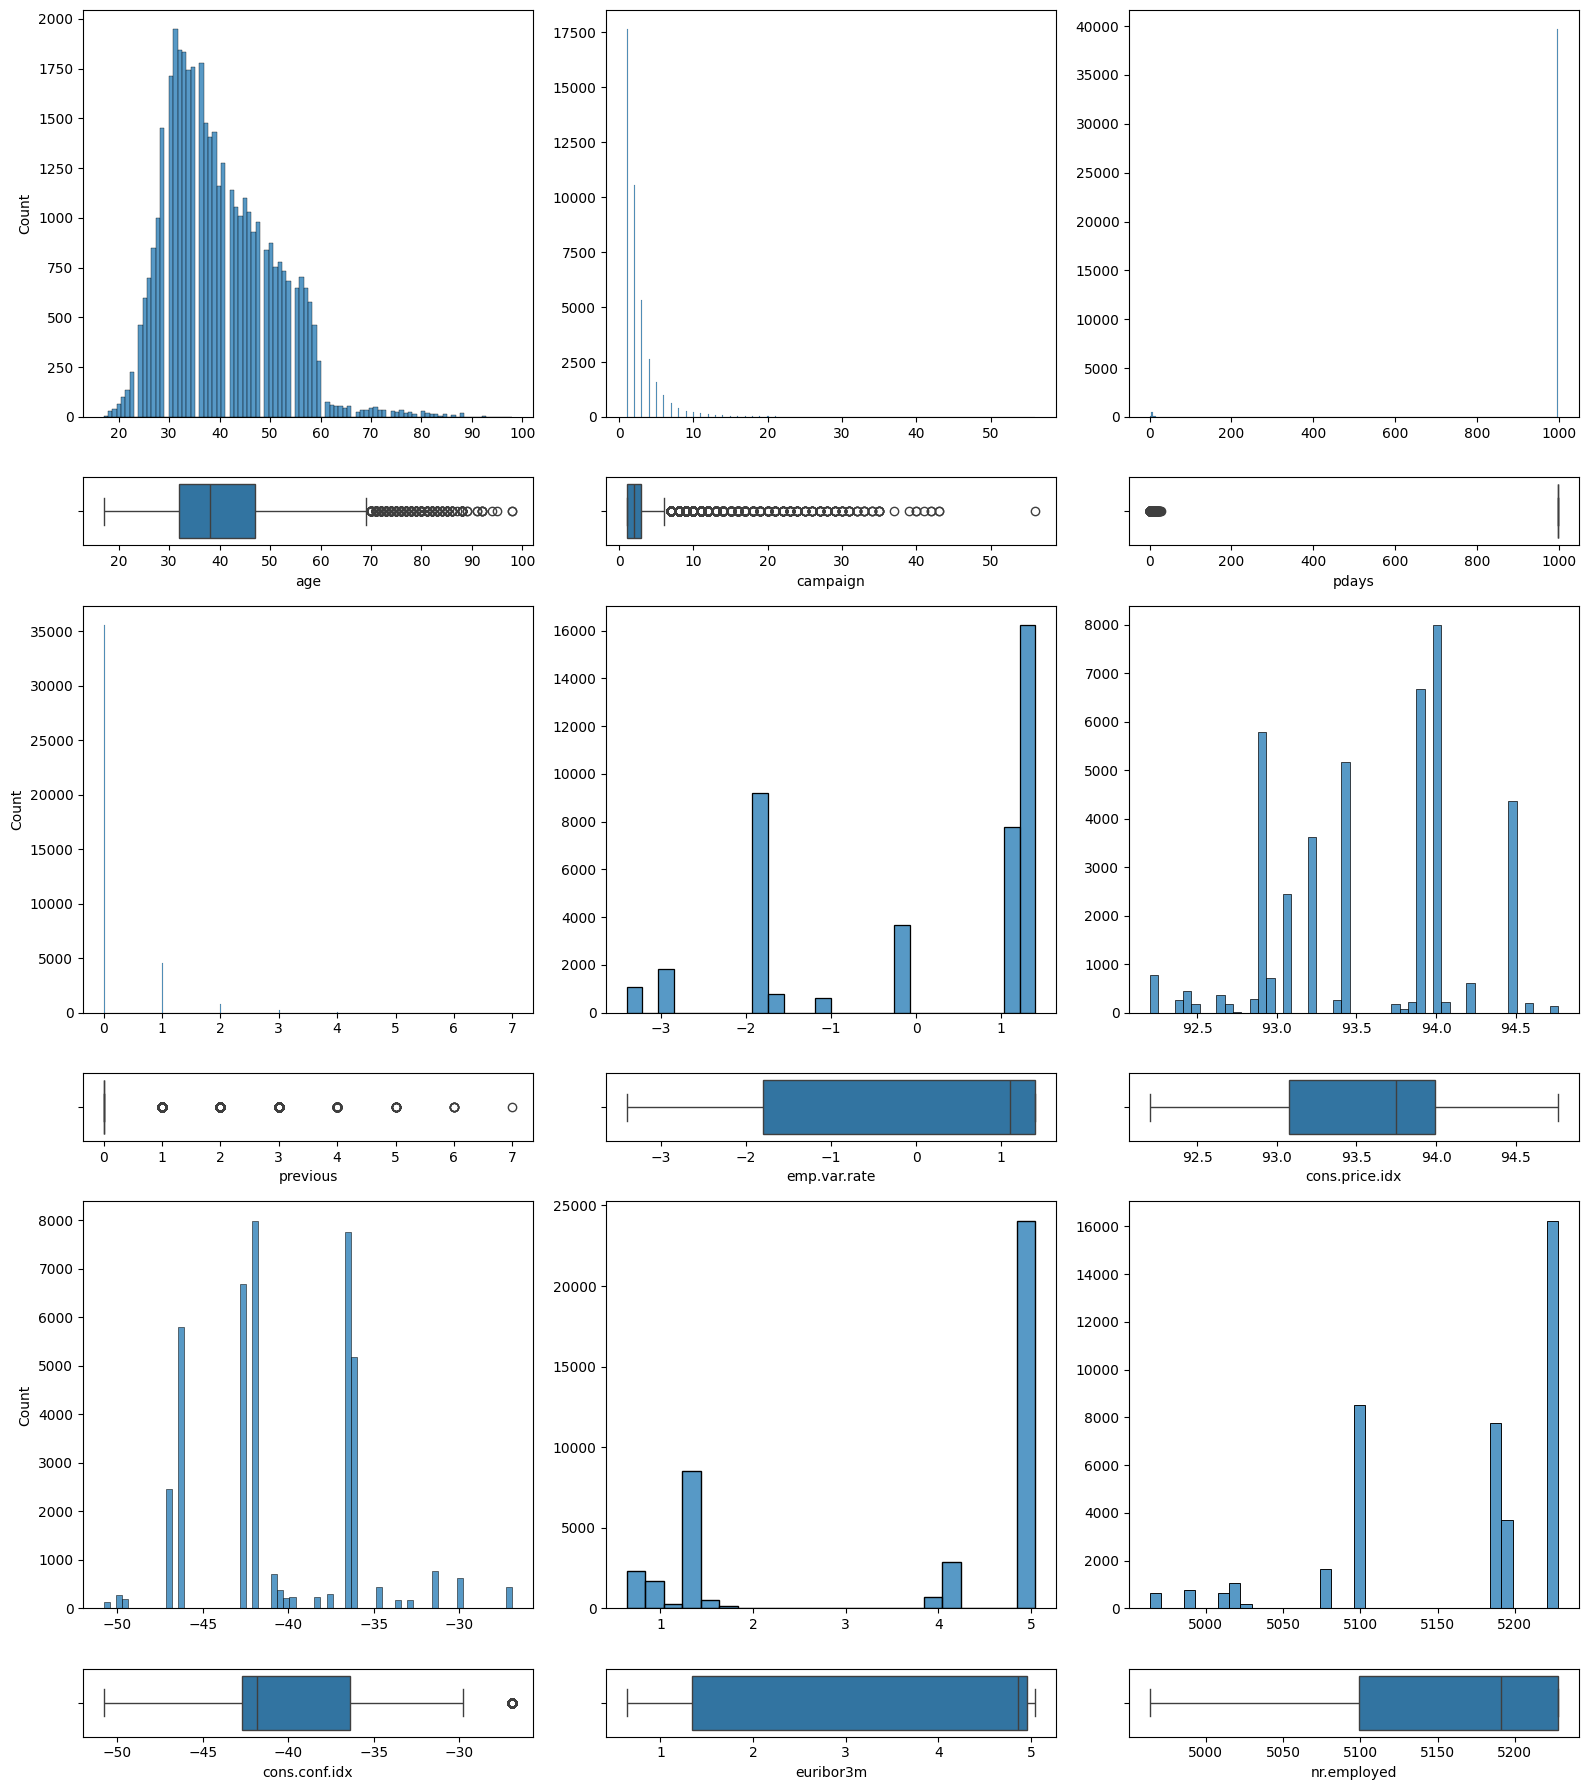

In [75]:
fig, axis = plt.subplots(6, 3, figsize=(16, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1]})

# age
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")

# campaign
sns.histplot(ax=axis[0, 1], data=df, x="campaign").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="campaign")

# pdays
sns.histplot(ax=axis[0, 2], data=df, x="pdays").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="pdays")

# previous
sns.histplot(ax=axis[2, 0], data=df, x="previous").set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df, x="previous")

# emp.var.rate
sns.histplot(ax=axis[2, 1], data=df, x="emp.var.rate").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df, x="emp.var.rate")

# cons.price.idx
sns.histplot(ax=axis[2, 2], data=df, x="cons.price.idx").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 2], data=df, x="cons.price.idx")

# cons.conf.idx
sns.histplot(ax=axis[4, 0], data=df, x="cons.conf.idx").set(xlabel=None)
sns.boxplot(ax=axis[5, 0], data=df, x="cons.conf.idx")

# euribor3m
sns.histplot(ax=axis[4, 1], data=df, x="euribor3m").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5, 1], data=df, x="euribor3m")

# nr.employed
sns.histplot(ax=axis[4, 2], data=df, x="nr.employed").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5, 2], data=df, x="nr.employed")

plt.tight_layout()
plt.show()

Chequeo en variables previous y pdays por tipo de gráfica

In [76]:
# Ver cuántos valores únicos y cuáles son
#previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)
print(f"valores únicos:",df['previous'].nunique())      # solo el número
print("="*50)
print(df['previous'].value_counts()) # el número y cuántas veces aparece cada uno

valores únicos: 8
previous
0    35551
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64


In [77]:
# Ver cuántos valores únicos y cuáles son
#pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
print(f"valores únicos:",df['pdays'].nunique())      #solo el número
print("="*50)
print(df['pdays'].value_counts()) # el número y cuántas veces aparece cada uno

valores únicos: 27
pdays
999    39661
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64


Conclusiones:

age:
La mayoría de los clientes tienen entre 30 y 50 años. Además, se  muestran algunos outliers.

campaign:
Hay muchos outliers hacia la derecha, lo que indica que algunos clientes fueron contactados un número muy elevado de veces (hasta 40). La distribución está muy sesgada a la derecha.

pdays:
La gran mayoría de valores se concentra en 999, que se puede interpretar que los clientes que no fueron contactados en una campaña anterior. Solo pocos tienen valores de días.

previous:
La mayoría de clientes tiene valor 0, lo que quiere decir que no fueron contactados antes en la anterior campaña. Se visualiza que es una variable muy sesgada.

emp.var.rate:
No se visualizan valores atípicos, la tasa de variación del emeplo se encuentra alrededor de -2 y 1.


cons.price.idx:
No se hallan valores atípicos.
El índice de precios al consumidor muestra varios picos y tiene conccentración de datos entre 93 y 94.

cons.conf.idx:
El índice de confianza del consumidor se distribuye entre valores negativos. se puede interpretar que los clientes se muestran reacios a contratar un depósito a largo plazo. Hay poco valores atípicos.

euribor3m:
No hay valores atípicos. La taza de euribor muestra valores concentrados en 5.


nr.employed:
No hay valores atípicos. Hay concentración de datos en los valores en 5100 y al rededor de 5200 

5. Análisis multivariante

5.1. Análisis numérico-numérico

Age-(cons.price.idx,cons.conf.idx)

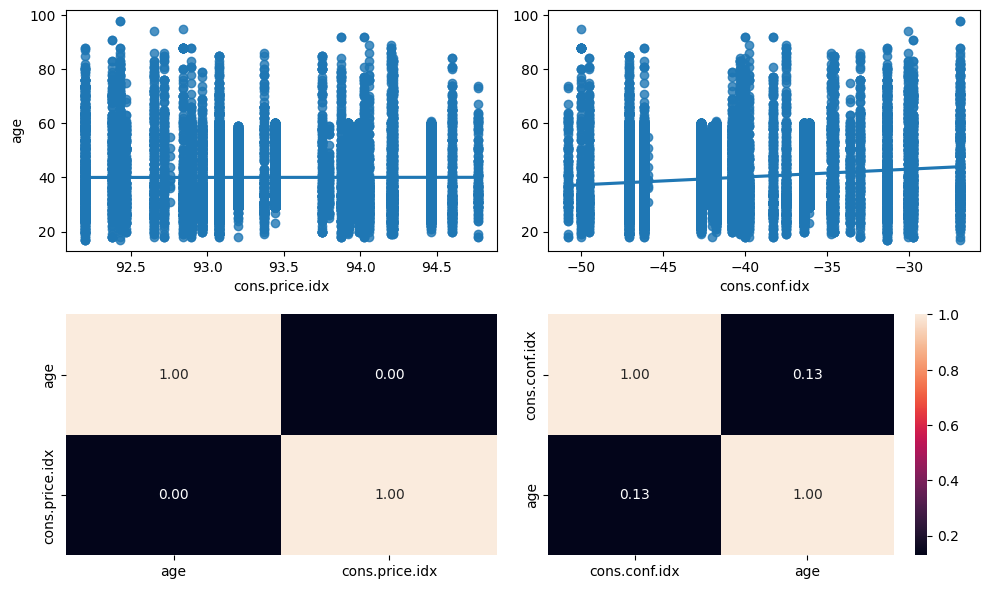

In [78]:
fig, axis = plt.subplots(2, 2, figsize = (10, 6))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "cons.price.idx", y = "age")
sns.heatmap(df[["age", "cons.price.idx"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "cons.conf.idx", y = "age").set(ylabel=None)
sns.heatmap(df[["cons.conf.idx", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

conclusiones age-indice economicos:

- age vs cons.price.idx: El gráfico muestra que no existe una relación fuerte entre la edad del cliente y el índice de precios al consumidor. La línea de regresión es prácticamente plana y la correlación es 0.00, lo que dice que las variables son independiente.

- age vs cons.conf.idx: La correlación es muy baja (0.13), esto quiere decir que la edad del cliente apenas tiene relación co el índice de confianza del consumidor.

euribor3m -(emp.var.rate,nr.employed)

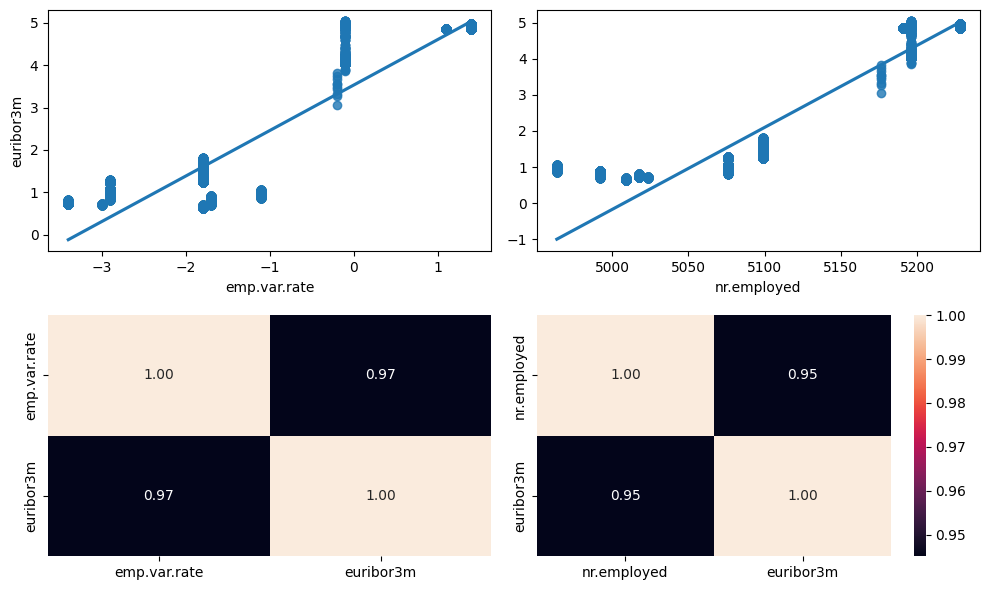

In [79]:
fig, axis = plt.subplots(2, 2, figsize = (10, 6))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "emp.var.rate", y = "euribor3m")
sns.heatmap(df[["emp.var.rate", "euribor3m"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "nr.employed", y = "euribor3m").set(ylabel=None)
sns.heatmap(df[["nr.employed", "euribor3m"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

conclusiones euribor3m vs indicadores económicos:

- euribor3m vs emp.var.rate: Se visualiza una correlación fuerte de 0.97 con tendencia positiva. Cuando la tasa de variación del empleo sube, el euribor también sube. 


- euribor3m vs nr.employed: También muestra una correlación fuerte de 0.95. A mayor número de empleados, mayor euribor. Estos tres indicadores económicos están muy relacionados entre sí.


6. Análisis categórico-categórico

y- (job,education,default,marital,housing,loan,contact,month)

/tmp/ipykernel_12572/511850954.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90)
/tmp/ipykernel_12572/511850954.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0, 2].set_xticklabels(axis[0, 2].get_xticklabels(), rotation=90)


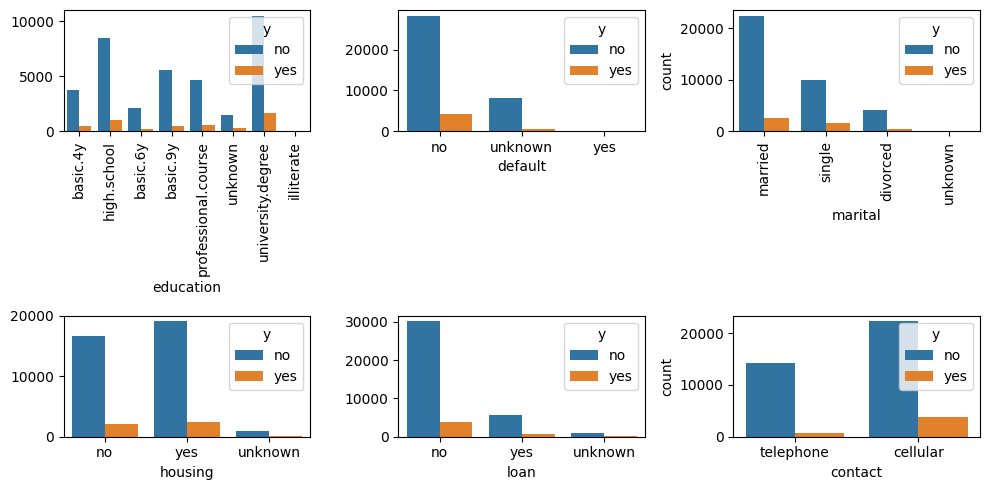

In [86]:
fig, axis = plt.subplots(2, 3, figsize = (10, 5))

sns.countplot(ax = axis[0, 0], data = df, x = "education", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 1], data = df, x = "default", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = df, x = "marital", hue = "y")
sns.countplot(ax = axis[1, 0], data = df, x = "housing", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 1], data = df, x = "loan", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 2], data = df, x = "contact", hue = "y")
#rotar etiquetas
axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90) 
axis[0, 2].set_xticklabels(axis[0, 2].get_xticklabels(), rotation=90) 
plt.tight_layout()

plt.show()

/tmp/ipykernel_12572/2781142988.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0].set_xticklabels(axis[0].get_xticklabels(), rotation=45)
/tmp/ipykernel_12572/2781142988.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[1].set_xticklabels(axis[1].get_xticklabels(), rotation=45)


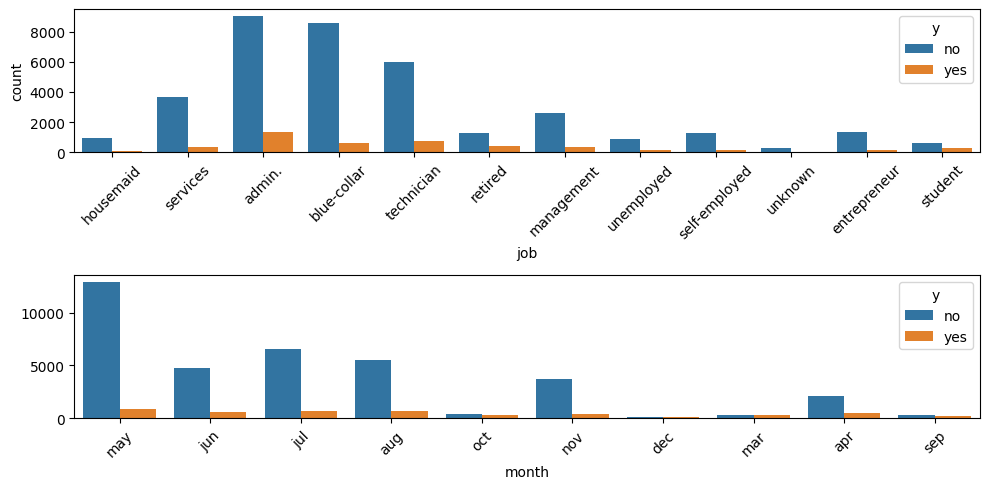

In [85]:
fig, axis = plt.subplots(2, 1, figsize = (10, 5))

sns.countplot(ax = axis[0], data = df, x = "job", hue = "y")

sns.countplot(ax = axis[1], data = df, x = "month", hue = "y").set(ylabel = None)



axis[0].set_xticklabels(axis[0].get_xticklabels(), rotation=45) 
axis[1].set_xticklabels(axis[1].get_xticklabels(), rotation=45) 

plt.tight_layout()

plt.show()